### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [56]:
data = pd.read_csv('data/coupons.csv')

In [57]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [58]:
#Let's looks at shape and info
print(data.shape)
data.info()

#look at missing data
data.isnull().sum()


(12684, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [59]:
#From the previous output, it is clear that CAR has only 108 non-null entries out of 12684. 
#So let's drop the column
data = data.drop(columns=['car'])

#For rest of the columns, we will drop the rows with missing values; 
#It's safe as its only 2% of total rows. Replacing them with mean/mode seems not too accurate. 
data = data.dropna()

4. What proportion of the total observations chose to accept the coupon?



In [60]:
print(f"Accepted coupon proportion is {data['Y'].mean():.4f}")
#Accepted coupon proprtion is 56.93%

Accepted coupon proportion is 0.5693


5. Use a bar plot to visualize the `coupon` column.

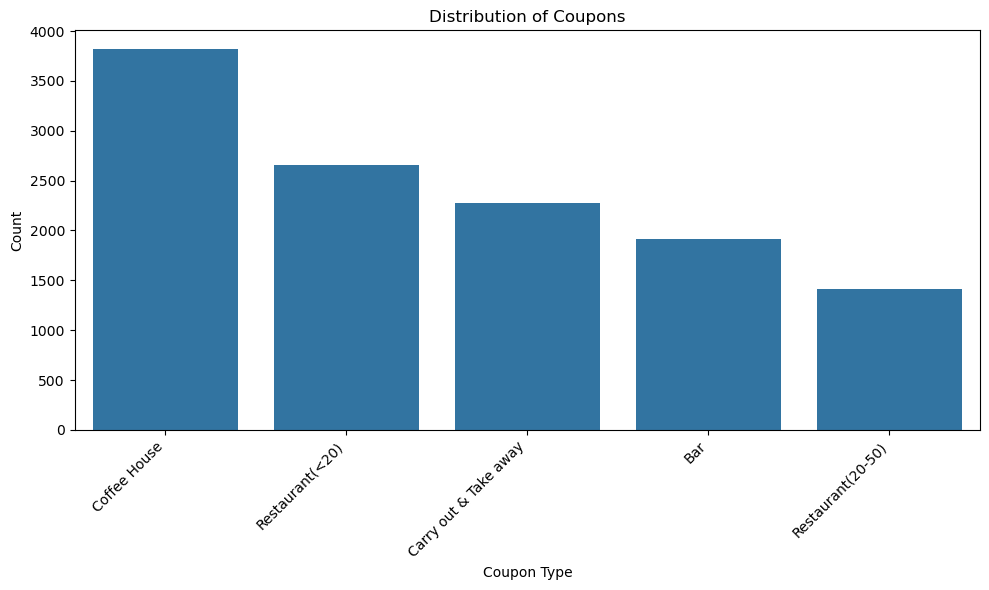

In [61]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, x="coupon", order=data['coupon'].value_counts().index) #count each coupon type appearance
plt.title('Distribution of Coupons')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha="right") # just making sure labels are not overlapping
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

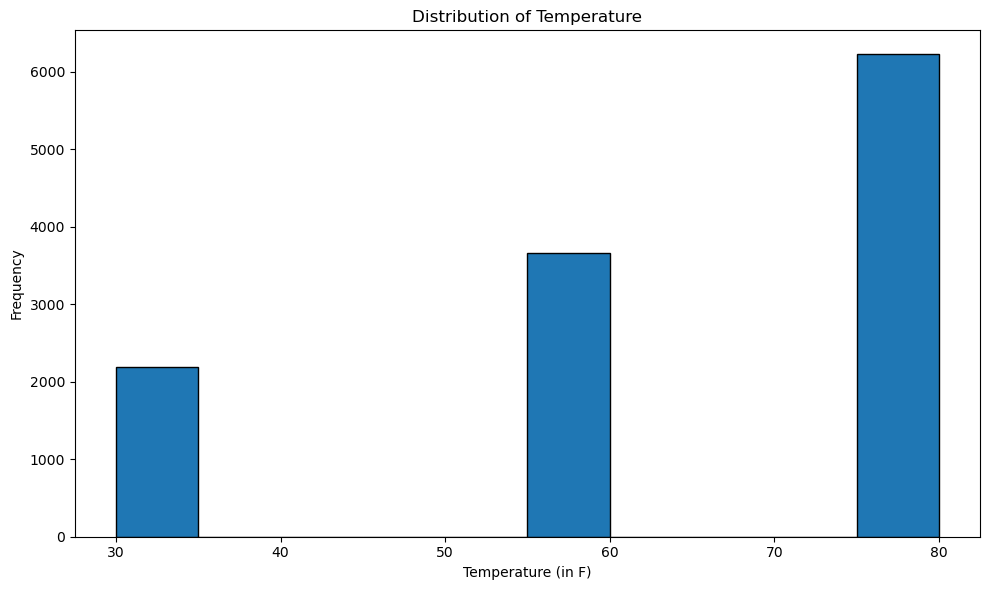

In [62]:
plt.figure(figsize=(10,6))
plt.hist(data['temperature'], bins=10, edgecolor='black')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (in F)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [63]:
bar_data = data[data['coupon']=='Bar']
print(f"Total coupons for Bar are {len(bar_data)}")
#Total coupons for Bar are 1913

Total coupons for Bar are 1913


2. What proportion of bar coupons were accepted?


In [64]:
bar_accepted_coupons = bar_data['Y'].mean()
print(f"The acceptance rate for Bar coupons is {bar_accepted_coupons:.4f}")
#The acceptance rate for Bar coupons is 0.4119

The acceptance rate for Bar coupons is 0.4119


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [65]:
#we are looking for data with "never", "1 to 3"or fewer
bar_less3 = bar_data[bar_data["Bar"].isin(["never","less1","1~3"])]
#we are looking for data for more than 3 visits
bar_more3 = bar_data[bar_data["Bar"].isin(["4~8","gt8"])]

print(f"Coupon Acceptance for less than or equal to 3 visits: {bar_less3['Y'].mean():.4f}")   # roughly 0.37
print(f"Coupon Acceptance for more than 3 visits: {bar_more3['Y'].mean():.4f}")    # roughly 0.76

Coupon Acceptance for less than or equal to 3 visits: 0.3727
Coupon Acceptance for more than 3 visits: 0.7617


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [66]:
age_over_25 = ['26','31','36','41','46','50plus']
bar_25_1 = bar_data[(bar_data["Bar"].isin(["1~3","4~8","gt8"])) & (bar_data["age"].isin(age_over_25))]
others = bar_data[~(bar_data["Bar"].isin(["1~3","4~8","gt8"])) & (bar_data["age"].isin(age_over_25))] #"~" sign means not

print(f"Coupon acceptance for someone going to bar more than once and is above 25 is {bar_25_1['Y'].mean():.4f}")
print(f"Coupon acceptance for others is {others['Y'].mean():.4f}")

#Coupon acceptance for someone going to bar more than once and is above 25 is 0.6898
#Coupon acceptance for others is 0.2674

Coupon acceptance for someone going to bar more than once and is above 25 is 0.6898
Coupon acceptance for others is 0.2674


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [67]:
#Goes to bar more than once a month, with passanger who is not kid, and occuaption is not farmin, fishing, or forestry
bar_sample = bar_data[(bar_data["Bar"].isin(["1~3", "4~8", "gt8"])) & (bar_data["passanger"]!="Kid(s)") & (bar_data["occupation"]!="Farming Fishing & Forestry")]

others = bar_data[~((bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['occupation'] != 'Farming Fishing & Forestry'))]

print(f"Coupon acceptance for someone going to bar more than once, no kids as passenger and occupation is NOT Farmin, Fishing and Forestry is {bar_sample['Y'].mean():.4f}")
print(f"Coupon acceptance for others is {others['Y'].mean():.4f}")

#Coupon acceptance for someone going to bar more than once, no kids as passenger and occupation is NOT Farmin, Fishing and Forestry is 0.7094
#Coupon acceptance for others is 0.2979

Coupon acceptance for someone going to bar more than once, no kids as passenger and occupation is NOT Farmin, Fishing and Forestry is 0.7094
Coupon acceptance for others is 0.2979


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [68]:
ages_under_30 = ['below21', '21', '26']
income_under_50k = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

sample1 = ((bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['maritalStatus'] != 'Widowed'))
sample2 = ((bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_data['age'].isin(ages_under_30)))
sample3 = ((bar_data['RestaurantLessThan20'].isin(['4~8', 'gt8'])) & (bar_data['income'].isin(income_under_50k)))

sample = bar_data[sample1 | sample2 | sample3]
others = bar_data[~(sample1 | sample2 | sample3)]

print(f"Coupon acceptance for given sample is {sample["Y"].mean():.4f}")
print(f"All others is {others["Y"].mean():.4f}")

#Coupon acceptance for given sample is 0.5871
#All others is 0.2999

Coupon acceptance for given sample is 0.5871
All others is 0.2999


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [69]:
# Drivers who accepted bar coupons tend to be 1) frequent bar visitors 2) Over 25 years old 3) Not travelling with children 4) not widowed. 
# ~77% of the drivers who goes to bar more than once a month are likely to accept the coupon. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [ ]:
#Picking Coffee House Coupons for this section
coffee = data[data["coupon"] == "Coffee House"]
print(f"Coffee house coupon acceptance rate is {coffee['Y'].mean():4f}")
#Coffee house coupon acceptance rate is 0.496331 (49%)

Coffee house coupon acceptance rate is 0.496331


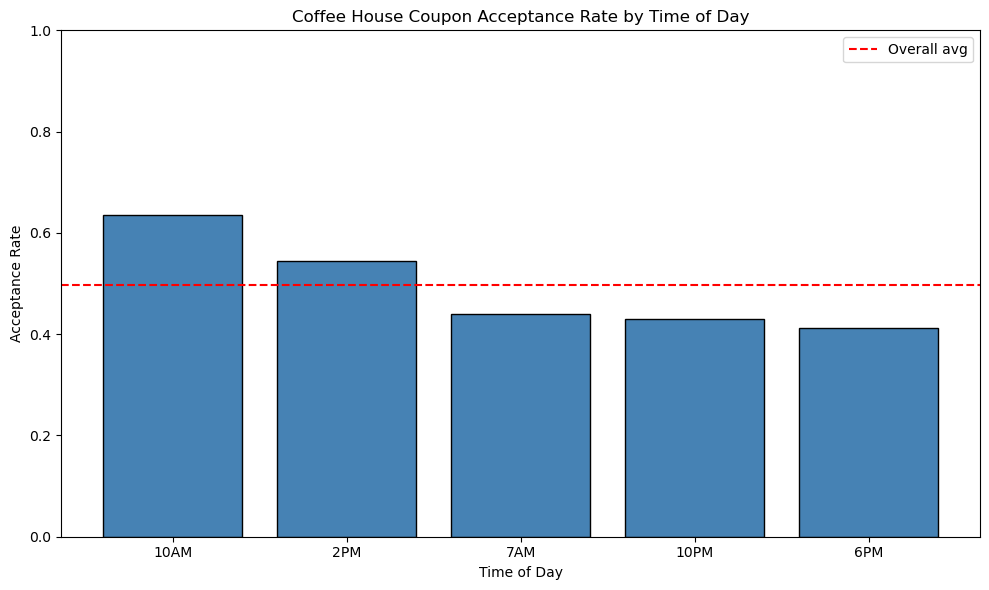

In [74]:
#Acceptance by Time of Day
time_acceptance = coffee.groupby('time')['Y'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(time_acceptance.index, time_acceptance.values, color='steelblue', edgecolor='black')
plt.title('Coffee House Coupon Acceptance Rate by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.axhline(y=coffee['Y'].mean(), color='red', linestyle='--', label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()

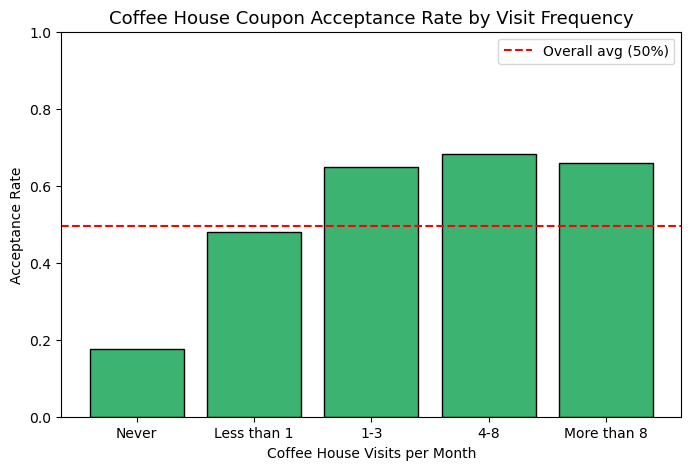

In [75]:
#Acceptance by number of visits
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
freq_labels = ['Never', 'Less than 1', '1-3', '4-8', 'More than 8']

freq_acceptance = coffee.groupby('CoffeeHouse')['Y'].mean().reindex(freq_order)
plt.figure(figsize=(8, 5))
bars = plt.bar(freq_labels, freq_acceptance.values, color='mediumseagreen', edgecolor='black')
plt.title('Coffee House Coupon Acceptance Rate by Visit Frequency', fontsize=13)
plt.xlabel('Coffee House Visits per Month')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1)
plt.axhline(y=coffee['Y'].mean(), color='red', linestyle='--', label='Overall avg (50%)')
plt.legend()

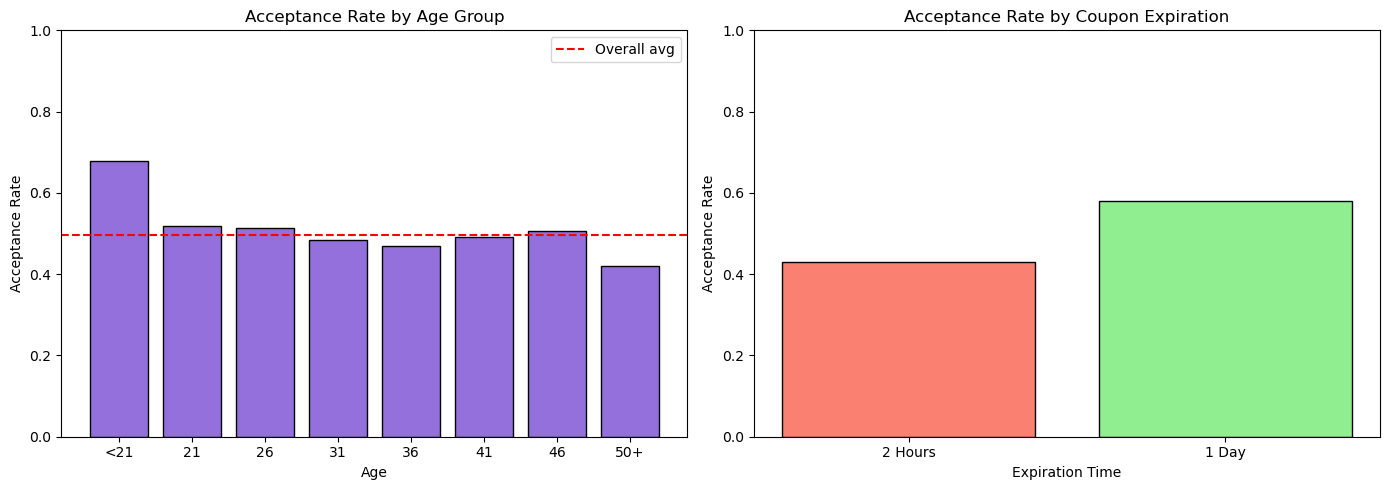

In [79]:
#Acceptance by age and expiration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#By age
age_order = ['below21', '21', '26', '31', '36', '41', '46', '50plus']
age_labels = ['<21', '21', '26', '31', '36', '41', '46', '50+']
age_acceptance = coffee.groupby('age')['Y'].mean().reindex(age_order)

axes[0].bar(age_labels, age_acceptance.values, color='mediumpurple', edgecolor='black')
axes[0].set_title('Acceptance Rate by Age Group', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Acceptance Rate')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=coffee['Y'].mean(), color='red', linestyle='--', label='Overall avg')
axes[0].legend()

#By Expiration
expire_accept = coffee.groupby('expiration')['Y'].mean()
axes[1].bar(['2 Hours', '1 Day'], [expire_accept['2h'], expire_accept['1d']], color=['salmon', 'lightgreen'], edgecolor='black')
axes[1].set_title('Acceptance Rate by Coupon Expiration', fontsize=12)
axes[1].set_xlabel('Expiration Time')
axes[1].set_ylabel('Acceptance Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [ ]:
#Key Findings for Coffee House coupons are 1) Nuber of visits to the coffee shop is god indicator.
# Driver with 1 to 3 time month visit are willing to accpet te couon by close to 60% time
# Same goes for time of day. 64% drivers are liekly to accept the coupon at 10AM. 
#interesting to see people with age less than 21 are likely to accepts che coupon - ~65% chance
# If coupon expiration is out by a day, chances are higher compared to 2 hr coupon expiration